In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [2]:
data_files = ['UNSW-NB15_1.csv', 'UNSW-NB15_2.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_4.csv']
dataframes = [pd.read_csv(file, header=None, low_memory=False) for file in data_files]
df = pd.concat(dataframes, ignore_index=True)
print("Merged Data Shape:", df.shape)


Merged Data Shape: (2540047, 49)


In [3]:
features=pd.read_csv('NUSW-NB15_features.csv',encoding='latin1')
features.head(49)


,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [4]:
import pandas as pd

# ✅ Step 1: Correct column names list (49 expected columns)
column_names = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes',
    'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts',
    'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
    'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat',
    'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd',
    'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label'
]
# ✅ Step 2: Read and merge CSVs (assuming data_files is already defined)
dataframes = [pd.read_csv(file, header=None, low_memory=False) for file in data_files]
df = pd.concat(dataframes, ignore_index=True)

# ✅ Step 3: Assign column names
df.columns = column_names

# ✅ Step 4: Confirm
print("Final dataset shape:", df.shape)
print("Final column count:", len(df.columns))
print(" Column names:")
print(df.columns.tolist())
import pandas as pd

# Fix column names
df.columns = df.columns.str.strip().str.lower()

# Check label distribution
print("Label distribution after merging and cleaning:")
print(df['label'].value_counts())


Final dataset shape: (2540047, 49)
Final column count: 49
 Column names:
['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label']
Label distribution after merging and cleaning:
label
0    2218764
1     321283
Name: count, dtype: int64


In [5]:
df.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


In [6]:
print("Number of rows:",df.shape[0])

Number of rows: 2540047


In [7]:
print("Number of columns:",df.shape[1])

Number of columns: 49


In [8]:
print("Shape of the dataset:",df.shape)


Shape of the dataset: (2540047, 49)


In [9]:

null_counts = df.isnull().sum().sort_values(ascending=False)
print("Top 3 columns with most null values:")
print(null_counts.head(3))

top_null_columns = null_counts.head(3).index.tolist()
df.drop(columns=top_null_columns,inplace=True)
print(f"\nDropped columns:{top_null_columns}")
print("Shape after dropping 3 columns with most nulls:",df.shape)

df.dropna(inplace=True)
print("Dataset shape after dropping any remaining nulls rows:",df.shape)

print(df.isnull().sum())
print("Total null values:",df.isnull().sum().sum())


Top 3 columns with most null values:
attack_cat          2218764
is_ftp_login        1429879
ct_flw_http_mthd    1348145
dtype: int64

Dropped columns:['attack_cat', 'is_ftp_login', 'ct_flw_http_mthd']
Shape after dropping 3 columns with most nulls: (2540047, 46)
Dataset shape after dropping any remaining nulls rows: (2540047, 46)
srcip               0
sport               0
dstip               0
dsport              0
proto               0
state               0
dur                 0
sbytes              0
dbytes              0
sttl                0
dttl                0
sloss               0
dloss               0
service             0
sload               0
dload               0
spkts               0
dpkts               0
swin                0
dwin                0
stcpb               0
dtcpb               0
smeansz             0
dmeansz             0
trans_depth         0
res_bdy_len         0
sjit                0
djit                0
stime               0
ltime               0
sintpkt

In [10]:
df.drop_duplicates(inplace=True)
print("Dataset shape after removing duplicates:",df.shape)

Dataset shape after removing duplicates: (2048617, 46)


In [43]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [41]:
cat_cols = ['proto', 'state', 'service']
for col in cat_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))


In [13]:
print("Columns in df:", df.columns.tolist())

Columns in df: ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'label']


In [14]:
print(df[['proto','state','service',]].head())

   proto  state  service
0    120      2        2
1    120      2        0
2    120      2        2
3    120      2        2
4    120      2        2


In [15]:
from sklearn.preprocessing import LabelEncoder

df['proto'] = df['proto'].astype(str) 
top_30_protos = df['proto'].value_counts().nlargest(30).index.tolist()
df = df[df['proto'].isin(top_30_protos)]

le_proto = LabelEncoder()
df['proto'] = le_proto.fit_transform(df['proto'])

label_encoders = {}
label_encoders['proto'] = le_proto


print(" Unique values after encoding:", df['proto'].nunique())
print(df['proto'].value_counts())

 Unique values after encoding: 30
proto
5     1448580
6      587930
20       6658
25       3137
8         728
16        498
29         76
17         54
14         21
15         15
28         14
19         14
3          13
26         13
1          13
22         13
4          13
24          8
7           8
0           8
11          8
2           8
9           8
23          7
18          7
21          7
10          7
12          7
13          7
27          7
Name: count, dtype: int64


In [16]:
numeric_cols=df.select_dtypes(include=[np.number]).columns.tolist()

if'label'in numeric_cols:
    numeric_cols.remove('label')
if'attack_cat'in numeric_cols:
    numeric_cols.remove('attack_cat')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("Scaling complete. Sample scaled data:")
print(df[numeric_cols].head())

Scaling complete. Sample scaled data:
      proto     state       dur    sbytes    dbytes      sttl      dttl  \
0  0.501134 -1.625915 -0.058047 -0.080024 -0.246825 -0.237359 -0.175553   
1  0.501134 -1.625915 -0.054872 -0.073666 -0.246002 -0.237359 -0.175553   
2  0.501134 -1.625915 -0.058041 -0.079800 -0.246743 -0.237359 -0.175553   
3  0.501134 -1.625915 -0.058033 -0.080024 -0.246825 -0.237359 -0.175553   
4  0.501134 -1.625915 -0.058036 -0.079800 -0.246743 -0.237359 -0.175553   

      sloss     dloss   service  ...    ackdat  is_sm_ips_ports  ct_state_ttl  \
0 -0.249528 -0.319367  0.074664  ... -0.129109        -0.036609      -0.22061   
1 -0.249528 -0.319367 -0.670193  ... -0.129109        -0.036609      -0.22061   
2 -0.249528 -0.319367  0.074664  ... -0.129109        -0.036609      -0.22061   
3 -0.249528 -0.319367  0.074664  ... -0.129109        -0.036609      -0.22061   
4 -0.249528 -0.319367  0.074664  ... -0.129109        -0.036609      -0.22061   

   ct_srv_src  ct_srv_ds

In [17]:
print("Mean after scaling:",df['dur'].mean())
print("std dev after scaling:",df['dur'].std())

Mean after scaling: 6.758855587543039e-18
std dev after scaling: 1.0000002441537188


In [18]:
from sklearn.preprocessing import LabelEncoder

top_30_protos = df['proto'].value_counts().nlargest(30).index
df['proto'] = df['proto'].apply(lambda x: x if x in top_30_protos else 'other')


df['proto'] = df['proto'].astype(str)

le_proto = LabelEncoder()
df['proto'] = le_proto.fit_transform(df['proto'])

label_encoders['proto'] = le_proto

print("Unique values after cardinality reduction in 'proto':", df['proto'].nunique()) 
print(df['proto'].value_counts())

Unique values after cardinality reduction in 'proto': 30
proto
0     1448580
6      587930
10       6658
15       3137
20        728
28        498
19         76
29         54
26         21
27         15
18         14
9          14
2          13
16         13
4          13
12         13
1          13
14          8
7           8
5           8
23          8
3           8
21          8
13          7
8           7
11          7
22          7
24          7
25          7
17          7
Name: count, dtype: int64


In [19]:
print("Columns in df:", df.columns.tolist())

Columns in df: ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'label']


In [20]:
cat_cols = ['proto', 'state', 'service']
df.drop_duplicates(inplace=True)
df.drop(columns=['attack_cat'], inplace=True, errors='ignore')

# ✅ Step 2: Simplify high-cardinality categorical features
df['proto'] = df['proto'].astype(str)
top_30 = df['proto'].value_counts().nlargest(30).index.tolist()
df['proto'] = df['proto'].apply(lambda x: x if x in top_30 else 'other')

df['state'] = df['state'].astype(str)
top_13 = df['state'].value_counts().nlargest(13).index.tolist()
df['state'] = df['state'].apply(lambda x: x if x in top_13 else 'other')

df['service'] = df['service'].astype(str)
top_10 = df['service'].value_counts().nlargest(10).index.tolist()
df['service'] = df['service'].apply(lambda x: x if x in top_10 else 'other')

# Filter to only include columns that still exist in the DataFrame
cat_cols = [col for col in cat_cols if col in df.columns]

# Now apply get_dummies only on existing columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Final feature set (excluding label if exists)
X = df.drop(columns=['label'], errors='ignore')
print("New feature set shape:", X.shape[1])



New feature set shape: 94


In [21]:
print("New feature set shape:",df.shape)
df.head()

New feature set shape: (2047887, 95)


,srcip,sport,dstip,dsport,dur,sbytes,dbytes,sttl,dttl,sloss,...,service_0.07466424951795207,service_0.44709292834991127,service_0.8195216071818705,service_1.1919502860138296,service_1.936807643677748,service_2.6816650013416665,service_3.0540936801736254,service_3.4265223590055847,service_3.798951037837544,service_other
0,59.166.0.0,1390,149.171.126.6,53,-0.058047,-0.080024,-0.246825,-0.237359,-0.175553,-0.249528,...,True,False,False,False,False,False,False,False,False,False
1,59.166.0.0,33661,149.171.126.9,1024,-0.054872,-0.073666,-0.246002,-0.237359,-0.175553,-0.249528,...,False,False,False,False,False,False,False,False,False,False
2,59.166.0.6,1464,149.171.126.7,53,-0.058041,-0.079800,-0.246743,-0.237359,-0.175553,-0.249528,...,True,False,False,False,False,False,False,False,False,False
3,59.166.0.5,3593,149.171.126.5,53,-0.058033,-0.080024,-0.246825,-0.237359,-0.175553,-0.249528,...,True,False,False,False,False,False,False,False,False,False
4,59.166.0.3,49664,149.171.126.0,53,-0.058036,-0.079800,-0.246743,-0.237359,-0.175553,-0.249528,...,True,False,False,False,False,False,False,False,False,False


In [22]:
print("total features:",df.shape[1])
#print("columns list:\n",df.columns.tolist())

total features: 95


In [23]:
print(df['label'].value_counts())

label
0    1959763
1      88124
Name: count, dtype: int64


In [24]:
from sklearn.utils import resample

# Step 1: Split the majority and minority classes
df_majority = df[df['label'] == 0]
df_minority = df[df['label'] == 1]

print("Before Downsampling:")
print("Majority class count:", len(df_majority))
print("Minority class count:", len(df_minority))

# Step 2: Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,                      # sample without replacement
    n_samples=len(df_minority),         # match minority class size
    random_state=42                     # for reproducibility
)

# Step 3: Combine minority class with downsampled majority
df_balanced = pd.concat([df_majority_downsampled, df_minority], ignore_index=True)

# Step 4: Shuffle the balanced dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter Downsampling:")
print(df_balanced['label'].value_counts())


Before Downsampling:
Majority class count: 1959763
Minority class count: 88124

After Downsampling:
label
1    88124
0    88124
Name: count, dtype: int64


In [25]:
column_names = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes',
    'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts',
    'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
    'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat',
    'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd',
    'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label'
]
# ✅ Step 2: Read and merge CSVs (assuming data_files is already defined)
dataframes = [pd.read_csv(file, header=None, low_memory=False) for file in data_files]
df = pd.concat(dataframes, ignore_index=True)

# ✅ Step 3: Assign column names
df.columns = column_names


In [26]:
from sklearn.utils import resample
import pandas as pd

# 1️⃣ Clean column names and data
df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)

# Check if 'attack_cat' exists
if 'attack_cat' not in df.columns:
    raise KeyError(" 'attack_cat' column not found. Check column names using df.columns.")

df.dropna(subset=['attack_cat'], inplace=True)
df['attack_cat'] = df['attack_cat'].astype(str).str.strip()

# 2️⃣ Show original attack_cat distribution
print("📊 Original 'attack_cat' distribution:\n")
print(df['attack_cat'].value_counts())

# 3️⃣ Choose balancing method: 'downsample' or 'upsample'
method = 'downsample'  # ← change to 'upsample' if needed

if method == 'downsample':
    target_size = df['attack_cat'].value_counts().min()
elif method == 'upsample':
    target_size = df['attack_cat'].value_counts().max()
else:
    raise ValueError("❌ Invalid method. Use 'downsample' or 'upsample'.")

# 4️⃣ Balance each attack category
balanced_data = []

for cat in df['attack_cat'].unique():
    subset = df[df['attack_cat'] == cat]
    if method == 'downsample':
        resampled = resample(subset, replace=False, n_samples=target_size, random_state=42)
    else:  # upsample
        resampled = resample(subset, replace=True, n_samples=target_size, random_state=42)
    balanced_data.append(resampled)

# 5️⃣ Combine all balanced categories
df_attack_balanced = pd.concat(balanced_data)
df_attack_balanced = df_attack_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 6️⃣ Final results
print("\n✅ Balanced 'attack_cat' distribution (method = '{}'):\n".format(method))
print(df_attack_balanced['attack_cat'].value_counts())
print("\n✅ Final dataset shape:", df_attack_balanced.shape)


📊 Original 'attack_cat' distribution:

attack_cat
Exploits          27599
Generic           25378
Fuzzers           21795
Reconnaissance    13357
DoS                5665
Analysis           2184
Backdoor           1684
Shellcode          1511
Backdoors           299
Worms               171
Name: count, dtype: int64

✅ Balanced 'attack_cat' distribution (method = 'downsample'):

attack_cat
Worms             171
Backdoor          171
Exploits          171
Analysis          171
Generic           171
Fuzzers           171
DoS               171
Shellcode         171
Backdoors         171
Reconnaissance    171
Name: count, dtype: int64

✅ Final dataset shape: (1710, 49)


In [27]:
print(df['attack_cat'].value_counts())

attack_cat
Exploits          27599
Generic           25378
Fuzzers           21795
Reconnaissance    13357
DoS                5665
Analysis           2184
Backdoor           1684
Shellcode          1511
Backdoors           299
Worms               171
Name: count, dtype: int64


In [28]:
import numpy as np
import pandas as pd

# Step 1: Select numeric columns for correlation (excluding 'Label')
numerical_cols_for_corr = df.select_dtypes(include=np.number).columns.tolist()
if 'Label' in numerical_cols_for_corr:
    numerical_cols_for_corr.remove('Label')

# Step 2: Compute absolute correlation matrix
corr_matrix_numeric = df[numerical_cols_for_corr].corr().abs()

# Step 3: Select upper triangle of correlation matrix
upper = corr_matrix_numeric.where(np.triu(np.ones(corr_matrix_numeric.shape), k=1).astype(bool))

# Step 4: Find highly correlated pairs above threshold
threshold = 0.95
highly_correlated_pairs_info = []
to_drop_based_on_intercorrelation = set()

for column in upper.columns:
    for row_index in upper.index:
        correlation_value = upper.loc[row_index, column]
        if correlation_value > threshold:
            highly_correlated_pairs_info.append(((row_index, column), correlation_value))

print(f"Highly correlated feature pairs (threshold > {threshold}):")
for pair_info in sorted(highly_correlated_pairs_info, key=lambda x: x[1], reverse=True):
    pair, corr_val = pair_info
    print(f"{pair[0]} and {pair[1]} : {corr_val:.4f}")

# Step 5: Drop based on specific feature relationships
# 1. dur = Ltime - Stime
if all(col in df.columns for col in ['dur', 'Stime', 'Ltime']):
    print("\n'dur' is present. Dropping 'Stime' and 'Ltime'.")
    to_drop_based_on_intercorrelation.update(['Stime', 'Ltime'])

# 2. sbytes vs sloss
if 'sbytes' in df.columns and 'sloss' in df.columns:
    if corr_matrix_numeric.loc['sbytes', 'sloss'] > threshold:
        to_drop_based_on_intercorrelation.add('sloss')

# 3. dbytes vs dloss and Dpkts
for col in ['dloss', 'Dpkts']:
    if col in df.columns and 'dbytes' in df.columns:
        if corr_matrix_numeric.loc['dbytes', col] > threshold:
            to_drop_based_on_intercorrelation.add(col)

# 4. swin vs dwin
if 'swin' in df.columns and 'dwin' in df.columns:
    if corr_matrix_numeric.loc['swin', 'dwin'] > threshold:
        to_drop_based_on_intercorrelation.add('dwin')

# 5. tcprtt vs synack and ackdat
for col in ['synack', 'ackdat']:
    if col in df.columns and 'tcprtt' in df.columns:
        if corr_matrix_numeric.loc['tcprtt', col] > threshold:
            to_drop_based_on_intercorrelation.add(col)

# Step 6: Drop columns and show summary
print(f"\nRefined features to drop due to high correlation: {list(to_drop_based_on_intercorrelation)}")
print(f"Number of features to drop: {len(to_drop_based_on_intercorrelation)}")

df.drop(columns=list(to_drop_based_on_intercorrelation), inplace=True, errors='ignore')

# Step 7: Final output
print(f"\nShape after dropping highly correlated features: {df.shape}")

# Step 8: Update list of numerical columns (excluding Label again)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Label' in numerical_cols:
    numerical_cols.remove('Label')


Highly correlated feature pairs (threshold > 0.95):
Stime and Ltime : 1.0000
swin and dwin : 1.0000
dbytes and dloss : 0.9994
sbytes and sloss : 0.9979
dttl and swin : 0.9967
dttl and dwin : 0.9966
sloss and Spkts : 0.9932
sbytes and Spkts : 0.9920
ct_srv_src and ct_srv_dst : 0.9872
dbytes and Dpkts : 0.9764
dloss and Dpkts : 0.9760
ct_srv_dst and ct_dst_src_ltm : 0.9684
Ltime and is_ftp_login : 0.9651
Stime and is_ftp_login : 0.9651
ct_srv_src and ct_dst_src_ltm : 0.9596
ct_dst_ltm and ct_src_dport_ltm : 0.9585
Sjit and Dintpkt : 0.9581
tcprtt and synack : 0.9531

'dur' is present. Dropping 'Stime' and 'Ltime'.

Refined features to drop due to high correlation: ['sloss', 'dloss', 'synack', 'Stime', 'Ltime', 'Dpkts', 'dwin']
Number of features to drop: 7

Shape after dropping highly correlated features: (99643, 42)


In [29]:
import numpy as np

# Select only numeric columns
numeric_cols = df_balanced.select_dtypes(include=np.number).columns.tolist()

# Optional: Remove the target from correlation columns (we'll handle it separately)
if 'label' in numeric_cols:
    numeric_cols.remove('label')


In [30]:
# Compute correlation with 'label'
correlations = df_balanced[numeric_cols + ['label']].corr()

# Extract correlations with the label column
label_corr = correlations['label'].drop('label').sort_values(key=abs, ascending=False)

# Display top correlations
print(" Top correlations with 'label':\n")
print(label_corr.head(20))


 Top correlations with 'label':

ct_state_ttl        0.840951
sttl                0.825864
dttl                0.572700
ackdat              0.507554
tcprtt              0.502369
synack              0.451403
dload              -0.433226
ltime               0.384193
stime               0.384193
dmeansz            -0.342512
ct_dst_src_ltm      0.275957
ct_dst_sport_ltm    0.263668
ct_src_dport_ltm    0.246032
sload               0.195922
ct_srv_src          0.154392
ct_srv_dst          0.145114
smeansz             0.115882
dpkts              -0.111647
swin               -0.108069
dwin               -0.106553
Name: label, dtype: float64


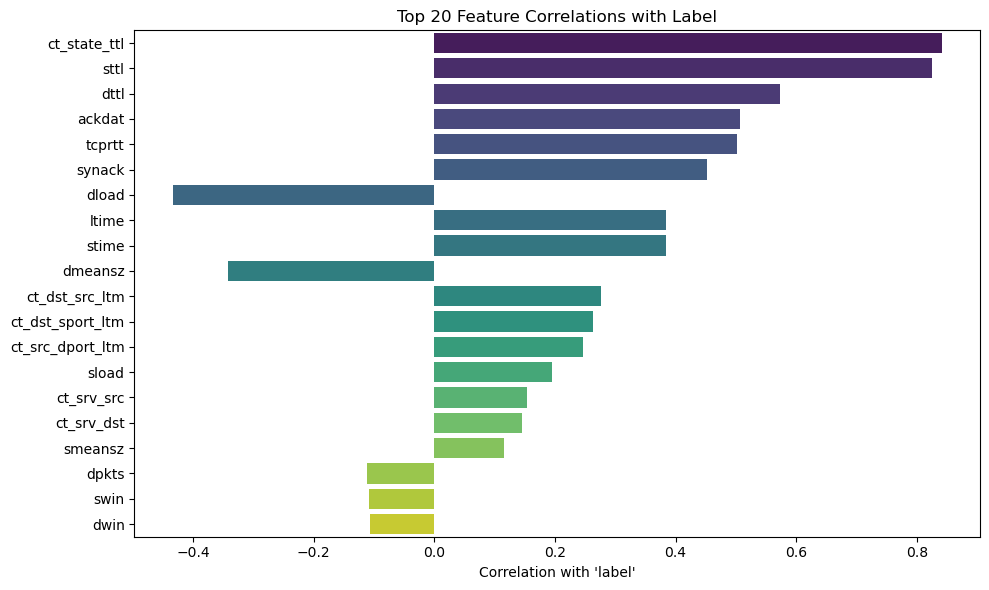

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=label_corr.head(20).values, y=label_corr.head(20).index, palette='viridis')
plt.title("Top 20 Feature Correlations with Label")
plt.xlabel("Correlation with 'label'")
plt.tight_layout()
plt.show()


In [32]:
column_names = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes',
    'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts',
    'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
    'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat',
    'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd',
    'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label'
]
# ✅ Step 2: Read and merge CSVs (assuming data_files is already defined)
dataframes = [pd.read_csv(file, header=None, low_memory=False) for file in data_files]
df = pd.concat(dataframes, ignore_index=True)

# ✅ Step 3: Assign column names
df.columns = column_names

# Fix column names
df.columns = df.columns.str.strip().str.lower()

# Check label distribution
print("Label distribution after merging and cleaning:")
print(df['label'].value_counts())


Label distribution after merging and cleaning:
label
0    2218764
1     321283
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd

# Drop rows with missing labels
df = df.dropna(subset=['label'])

# Convert label to int (if not already)
df['label'] = df['label'].astype(int)

# Show original label distribution
label_counts = df['label'].value_counts()
print("Original label distribution:\n", label_counts)

# ✅ Check if both 0 and 1 exist
if set(label_counts.index) == {0, 1}:
    sample_size = min(100000, len(df))
    sss = StratifiedShuffleSplit(n_splits=1, train_size=sample_size, random_state=42)
    for train_idx, _ in sss.split(df, df['label']):
        df_sampled = df.iloc[train_idx]
    print("\nSampled label distribution:\n", df_sampled['label'].value_counts())
else:
    print("\n❌ Cannot stratify: Only one class present in the label column.")
    print("Tip: Ensure you combine all CSV files correctly and that no filtering removed label=0 rows.")


Original label distribution:
 label
0    2218764
1     321283
Name: count, dtype: int64

Sampled label distribution:
 label
0    87351
1    12649
Name: count, dtype: int64


In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


df.drop_duplicates(inplace=True)
df.drop(columns=['attack_cat'],inplace=True,errors='ignore')

df['proto'] = df['proto'].astype(str)
top_30 = df['proto'].value_counts().nlargest(30).index.tolist()
df['proto']  = df['proto'].apply(lambda x:x if x in top_30 else 'other')

df['state'] = df['state'].astype(str)
top_13 = df['state'].value_counts().nlargest(13).index.tolist()
df['state']  = df['state'].apply(lambda x:x if x in top_13 else 'other')

df['service'] = df['service'].astype(str)
top_10 = df['service'].value_counts().nlargest(10).index.tolist()
df['service']  = df['service'].apply(lambda x:x if x in top_10 else 'other')


# ✅ 1. Clean column names
df.columns = df.columns.str.strip().str.replace(r"\s+", "_", regex=True)

# ✅ 2. Sample a portion to manage memory (optional but useful)
df_sampled = df.sample(n=100000, random_state=42)

# ✅ 3. Split into features and label
y = df_sampled['label']
X = df_sampled.drop(columns=['label'], errors='ignore')

# ✅ 4. Keep only numeric features
X = X.select_dtypes(include=[np.number])

# ✅ 5. Fill missing values with median
X = X.fillna(X.median(numeric_only=True))

# ✅ 6. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ✅ 7. Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ✅ 8. Compute feature importances
importances = rf.feature_importances_
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# ✅ 9. Extract Top 40 Features from the current training set
top_40_features = features_df['Feature'].head(40).tolist()

# ✅ 10. Select those 40 features directly from the cleaned numeric dataset (X)
X_reduced = X[top_40_features].copy()

# ✅ 11. Add label back from df_sampled to keep shape consistent
X_reduced['label'] = y.values

# ✅ 12. Print outputs
print(" Top 40 Features by Random Forest Importance:")
print(features_df.head(40))

print(f"\n Final Reduced Feature Set Shape : {X_reduced.shape}")


 Top 40 Features by Random Forest Importance:
             Feature  Importance
3               sttl    0.159966
29      ct_state_ttl    0.159135
4               dttl    0.061749
26            synack    0.054799
27            ackdat    0.050250
16           dmeansz    0.049060
2             dbytes    0.046462
25            tcprtt    0.045312
1             sbytes    0.041453
8              dload    0.039742
7              sload    0.035193
15           smeansz    0.034265
10             dpkts    0.022640
33        ct_srv_dst    0.021403
38    ct_dst_src_ltm    0.018188
32        ct_srv_src    0.017422
24           dintpkt    0.016607
0                dur    0.014170
23           sintpkt    0.013210
22             ltime    0.010963
21             stime    0.010620
37  ct_dst_sport_ltm    0.008567
19              sjit    0.008171
5              sloss    0.007734
20              djit    0.007455
14             dtcpb    0.006178
34        ct_dst_ltm    0.006018
13             stcpb    0.0057

In [35]:
from sklearn.model_selection import train_test_split

# Separate features and label again
X_final = X_reduced.drop(columns=['label'])
y_final = X_reduced['label']

# Perform 80/20 train-test split
X_train_40, X_test_40, y_train_40, y_test_40 = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Print the shapes
print("Train feature shape:", X_train_40.shape)
print("Test feature shape:", X_test_40.shape)
print("Train label distribution:\n", y_train_40.value_counts(normalize=True))
print("Test label distribution:\n", y_test_40.value_counts(normalize=True))


Train feature shape: (80000, 39)
Test feature shape: (20000, 39)
Train label distribution:
 label
0    0.951488
1    0.048513
Name: proportion, dtype: float64
Test label distribution:
 label
0    0.9515
1    0.0485
Name: proportion, dtype: float64


In [36]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ✅ Step 1: Separate features and label
y = df['label']  # assuming 'label' column exists
X = df.drop(columns=['label'])

# ✅ Step 2: Select only numeric columns (if not already)
X = X.select_dtypes(include=[np.number])

# ✅ Step 3: Fill missing values with median
X = X.fillna(X.median(numeric_only=True))

# ✅ Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ Step 5: Train Random Forest for Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ✅ Step 6: Get Top 40 Features
importances = rf.feature_importances_
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_40_features = features_df['Feature'].head(40).tolist()

# ✅ Step 7: Reduce Dataset
X_top40 = X[top_40_features].copy()
X_top40['label'] = y.values

# ✅ Step 8: Final Train-Test Split
X_final = X_top40.drop(columns=['label'])
y_final = X_top40['label']

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# ✅ Step 9: Output
print("\n🎯 Top 40 Features Selected:")
print(features_df.head(40))

print("\n📊 Final Shapes After Reduction:")
print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)
print("y_train_final:", y_train_final.shape)
print("y_test_final :", y_test_final.shape)



🎯 Top 40 Features Selected:
             Feature  Importance
3               sttl    0.161573
29      ct_state_ttl    0.146308
4               dttl    0.071742
27            ackdat    0.061733
26            synack    0.054903
16           dmeansz    0.053176
2             dbytes    0.045899
25            tcprtt    0.041705
15           smeansz    0.039186
1             sbytes    0.038538
7              sload    0.035742
8              dload    0.031967
10             dpkts    0.023764
33        ct_srv_dst    0.022011
32        ct_srv_src    0.019551
38    ct_dst_src_ltm    0.018237
24           dintpkt    0.017801
0                dur    0.013216
21             stime    0.011917
22             ltime    0.011879
23           sintpkt    0.010838
19              sjit    0.007542
37  ct_dst_sport_ltm    0.007322
20              djit    0.006321
9              spkts    0.005520
13             stcpb    0.005231
34        ct_dst_ltm    0.004874
14             dtcpb    0.004522
5             

🎯 Random Forest Results
Accuracy: 0.9990950226244344
Confusion Matrix:
 [[201665    119]
 [    66   2575]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    201784
           1       0.96      0.98      0.97      2641

    accuracy                           1.00    204425
   macro avg       0.98      0.99      0.98    204425
weighted avg       1.00      1.00      1.00    204425

🎯 Logistic Regression Results
Accuracy: 0.9871835636541519
Confusion Matrix:
 [[201731     53]
 [  2567     74]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    201784
           1       0.58      0.03      0.05      2641

    accuracy                           0.99    204425
   macro avg       0.79      0.51      0.52    204425
weighted avg       0.98      0.99      0.98    204425



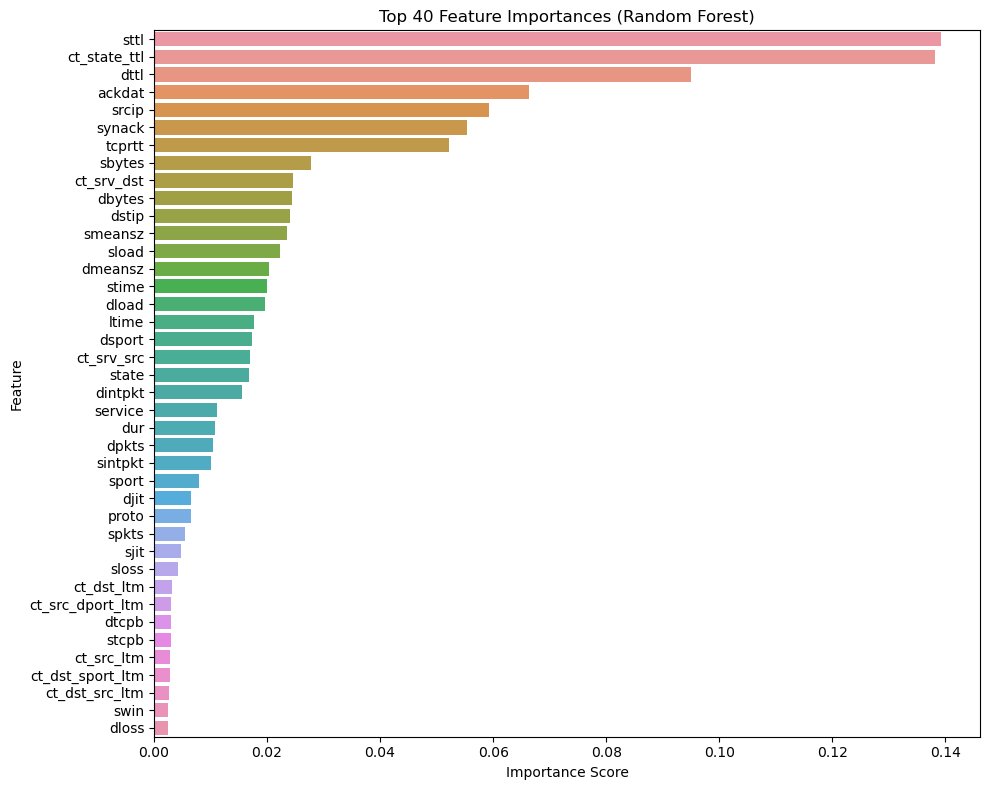

['top_40_features.pkl']

In [37]:
# 📦 1. Imports
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 🧹 2. Drop duplicates and NaNs
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)  # <-- FIXED: drop missing values
df.drop(columns=['attack_cat'], inplace=True, errors='ignore')

# 🧼 3. Encode categorical columns
from sklearn.preprocessing import LabelEncoder
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# 🎯 4. Split features and target
X = df.drop(columns=['label'], errors='ignore')
y = df['label']

# 🌲 5. Train Random Forest to get feature importances
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X, y)

# 🏆 6. Select Top 40 Features
importances = pd.Series(rf_temp.feature_importances_, index=X.columns)
top_40_features = importances.sort_values(ascending=False).head(40).index.tolist()
X_top40 = X[top_40_features]

# 🔀 7. Train-Test Split
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_top40, y, test_size=0.2, random_state=42, stratify=y
)

# 🌳 8. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train_final)
rf_pred = rf_model.predict(X_test_final)

# ➕ 9. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_final, y_train_final)
lr_pred = lr_model.predict(X_test_final)

# 🧪 10. Evaluate Models
print("🎯 Random Forest Results")
print("Accuracy:", accuracy_score(y_test_final, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_final, rf_pred))
print("Classification Report:\n", classification_report(y_test_final, rf_pred))

print("🎯 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test_final, lr_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_final, lr_pred))
print("Classification Report:\n", classification_report(y_test_final, lr_pred))

# 📊 11. Plot Feature Importances
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Top 40 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 💾 12. Save Models and Feature List
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(top_40_features, 'top_40_features.pkl')
